# Experiment 1 & 2: Image Classification — Evaluation

Loads trained checkpoints for ResNet-18 (baseline) and ResNet-18 (customised) and evaluates
both models. Run after `A2_Classification_P1_Training.ipynb`.

**Student ID**: 26045171

In [1]:
import random
from collections import defaultdict
from sklearn.model_selection import train_test_split
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

In [2]:
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT  = Path("26045171/Image_Classification/dataset")
EXP1_DIR      = Path("runs/exp1_resnet18")
EXP2_DIR      = Path("runs/exp2_resnet18_shallow")

NUM_CLASSES   = 10
BATCH_SIZE    = 256

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
base_dataset = ImageFolder(DATASET_ROOT)
CLASS_NAMES  = base_dataset.classes
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Total images: {len(base_dataset)}")

indices = list(range(len(base_dataset)))
labels  = [label for _, label in base_dataset.imgs]

train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=STUDENT_ID)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=STUDENT_ID)

all_by_class = defaultdict(list)
for idx, (_, lbl) in enumerate(base_dataset.imgs):
    all_by_class[lbl].append(idx)

tr_set, va_set = set(train_idx), set(val_idx)
print(f"\n{'Class':<22} {'Total':>5} {'Train':>5} {'Val':>4} {'Test':>4}")
print("-" * 44)
for lbl, name in enumerate(CLASS_NAMES):
    idxs = all_by_class[lbl]
    tr   = sum(1 for i in idxs if i in tr_set)
    va   = sum(1 for i in idxs if i in va_set)
    te   = len(idxs) - tr - va
    print(f"  {name:<20} {len(idxs):>5} {tr:>5} {va:>4} {te:>4}")
print("-" * 44)
print(f"  {'Total':<20} {len(base_dataset):>5} {len(train_idx):>5} {len(val_idx):>4} {len(test_idx):>4}")

Classes (10): ['Appenzeller', 'Lakeland_terrier', 'Leonberg', 'Samoyed', 'Weimaraner', 'Yorkshire_terrier', 'affenpinscher', 'briard', 'otterhound', 'schipperke']
Total images: 1707

Class                  Total Train  Val Test
--------------------------------------------
  Appenzeller            151   106   23   22
  Lakeland_terrier       197   138   29   30
  Leonberg               210   147   31   32
  Samoyed                218   152   33   33
  Weimaraner             160   112   24   24
  Yorkshire_terrier      164   115   24   25
  affenpinscher          150   105   23   22
  briard                 152   106   23   23
  otterhound             151   105   23   23
  schipperke             154   108   23   23
--------------------------------------------
  Total                 1707  1194  256  257


In [4]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

train_ds = TransformDataset(Subset(base_dataset, train_idx), val_transform)
val_ds   = TransformDataset(Subset(base_dataset, val_idx),   val_transform)
test_ds  = TransformDataset(Subset(base_dataset, test_idx),  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1194 | Val: 256 | Test: 257


In [5]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader, batch_size):
    model.eval()
    running_loss = 0.0
    total_images = 0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * batch_size
        total_images += batch_size
        metric.update(outputs, labels)
    return running_loss / total_images, metric.compute().item()

In [6]:
class BasicBlock(nn.Module):
    """Two 3×3 conv layers with a residual skip connection (He et al., 2016)."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        # 1×1 projection shortcut when spatial size or channel count changes
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


def _make_layer(in_channels, out_channels, num_blocks, stride=1):
    layers = [BasicBlock(in_channels, out_channels, stride)]
    for _ in range(1, num_blocks):
        layers.append(BasicBlock(out_channels, out_channels))
    return nn.Sequential(*layers)


class ResNet18(nn.Module):
    """
    ResNet-18 (baseline).
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256) → layer4(512)
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 17
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.layer4  = _make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.fc(torch.flatten(self.avgpool(x), 1))


class ResNet18Shallow(nn.Module):
    """
    ResNet-18 (customised) — layer4 removed.
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256)   ← layer4 omitted
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 13 (vs 17 in baseline)
    Feature dimension entering classifier: 256 (vs 512 in baseline)
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer3(self.layer2(self.layer1(x)))
        return self.fc(torch.flatten(self.avgpool(x), 1))


## Load Trained Models

In [7]:
def build_resnet18(num_classes):
    model      = ResNet18(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    model.layer4.load_state_dict(pretrained.layer4.state_dict())
    return model

model1     = build_resnet18(NUM_CLASSES).to(DEVICE)
model1.load_state_dict(torch.load(EXP1_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model1.eval()
total1     = sum(p.numel() for p in model1.parameters())
trainable1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"ResNet-18 (Baseline) loaded — {total1:,} params ({trainable1:,} trainable)")

ResNet-18 (Baseline) loaded — 11,181,642 params (11,181,642 trainable)


In [8]:
def build_resnet18_shallow(num_classes):
    model      = ResNet18Shallow(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    return model

model2     = build_resnet18_shallow(NUM_CLASSES).to(DEVICE)
model2.load_state_dict(torch.load(EXP2_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model2.eval()
total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"ResNet-18 (Customised) loaded — {total2:,} params ({trainable2:,} trainable)")

ResNet-18 (Customised) loaded — 2,785,354 params (2,785,354 trainable)


## Evaluation

In [9]:
# Evaluate all splits with consistent val_transform (no augmentation)
cm_metric1 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
cm_metric2 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)

_, train_acc1 = evaluate(model1, train_loader, BATCH_SIZE)
_, val_acc1   = evaluate(model1, val_loader,   BATCH_SIZE)
_, test_acc1  = evaluate(model1, test_loader,  BATCH_SIZE)

_, train_acc2 = evaluate(model2, train_loader, BATCH_SIZE)
_, val_acc2   = evaluate(model2, val_loader,   BATCH_SIZE)
_, test_acc2  = evaluate(model2, test_loader,  BATCH_SIZE)

with torch.no_grad():
    for imgs, lbls in test_loader:
        cm_metric1.update(model1(imgs.to(DEVICE)), lbls.to(DEVICE))
        cm_metric2.update(model2(imgs.to(DEVICE)), lbls.to(DEVICE))

cm1            = cm_metric1.compute().cpu().numpy()
cm2            = cm_metric2.compute().cpu().numpy()
per_class_acc1 = cm1.diagonal() / cm1.sum(axis=1)
per_class_acc2 = cm2.diagonal() / cm2.sum(axis=1)

print("=== Exp 1 — ResNet-18 (Baseline) ===")
print(f"  Train: {train_acc1:.4f} | Val: {val_acc1:.4f} | Test: {test_acc1:.4f}")
print("\nPer-class test accuracy:")
for name, acc in zip(CLASS_NAMES, per_class_acc1):
    print(f"  {name:<22}: {acc:.4f}")

print("\n=== Exp 2 — ResNet-18 (Customised) ===")
print(f"  Train: {train_acc2:.4f} | Val: {val_acc2:.4f} | Test: {test_acc2:.4f}")
print("\nPer-class test accuracy:")
for name, acc in zip(CLASS_NAMES, per_class_acc2):
    print(f"  {name:<22}: {acc:.4f}")

=== Exp 1 — ResNet-18 (Baseline) ===
  Train: 1.0000 | Val: 0.9297 | Test: 0.9620

Per-class test accuracy:
  Appenzeller           : 0.9545
  Lakeland_terrier      : 0.9667
  Leonberg              : 1.0000
  Samoyed               : 1.0000
  Weimaraner            : 1.0000
  Yorkshire_terrier     : 0.9600
  affenpinscher         : 1.0000
  briard                : 0.9565
  otterhound            : 0.8261
  schipperke            : 0.9565

=== Exp 2 — ResNet-18 (Customised) ===
  Train: 0.9896 | Val: 0.8668 | Test: 0.8467

Per-class test accuracy:
  Appenzeller           : 0.8636
  Lakeland_terrier      : 0.5667
  Leonberg              : 0.9062
  Samoyed               : 0.9394
  Weimaraner            : 0.8750
  Yorkshire_terrier     : 0.8400
  affenpinscher         : 0.9545
  briard                : 0.8261
  otterhound            : 0.8696
  schipperke            : 0.8261


## Comparison — Exp 1 vs Exp 2

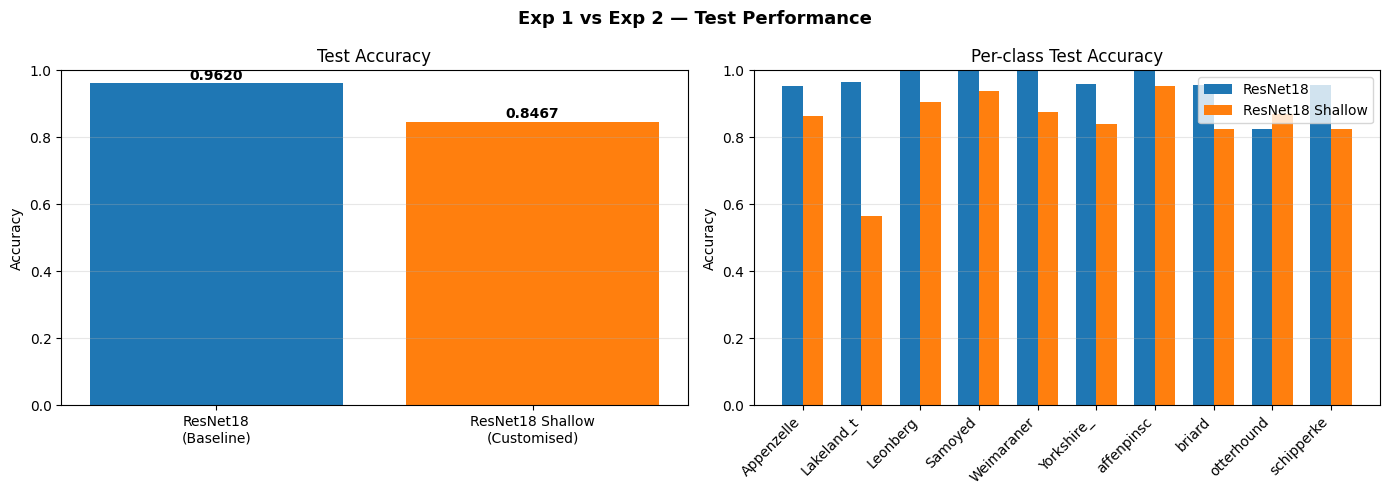


Parameter comparison:
  ResNet18 (Exp 1):         11,181,642 params
  ResNet18 Shallow (Exp 2):  2,785,354 params
  Reduction:                75.1%


In [10]:
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_labels = ["ResNet18\n(Baseline)", "ResNet18 Shallow\n(Customised)"]
accs         = [test_acc1, test_acc2]
bars = axes[0].bar(range(2), accs, color=["tab:blue", "tab:orange"])
axes[0].set_xticks(range(2))
axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0, 1)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
                 f"{acc:.4f}", ha="center", fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)

x = np.arange(NUM_CLASSES)
axes[1].bar(x - width / 2, per_class_acc1, width, label="ResNet18",         color="tab:blue")
axes[1].bar(x + width / 2, per_class_acc2, width, label="ResNet18 Shallow", color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels([c[:10] for c in CLASS_NAMES], rotation=45, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Per-class Test Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Exp 1 vs Exp 2 \u2014 Test Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_comparison.png", dpi=150)
plt.show()

print(f"\nParameter comparison:")
print(f"  ResNet18 (Exp 1):         {total1:>10,} params")
print(f"  ResNet18 Shallow (Exp 2): {total2:>10,} params")
print(f"  Reduction:                {(1 - total2 / total1) * 100:.1f}%")

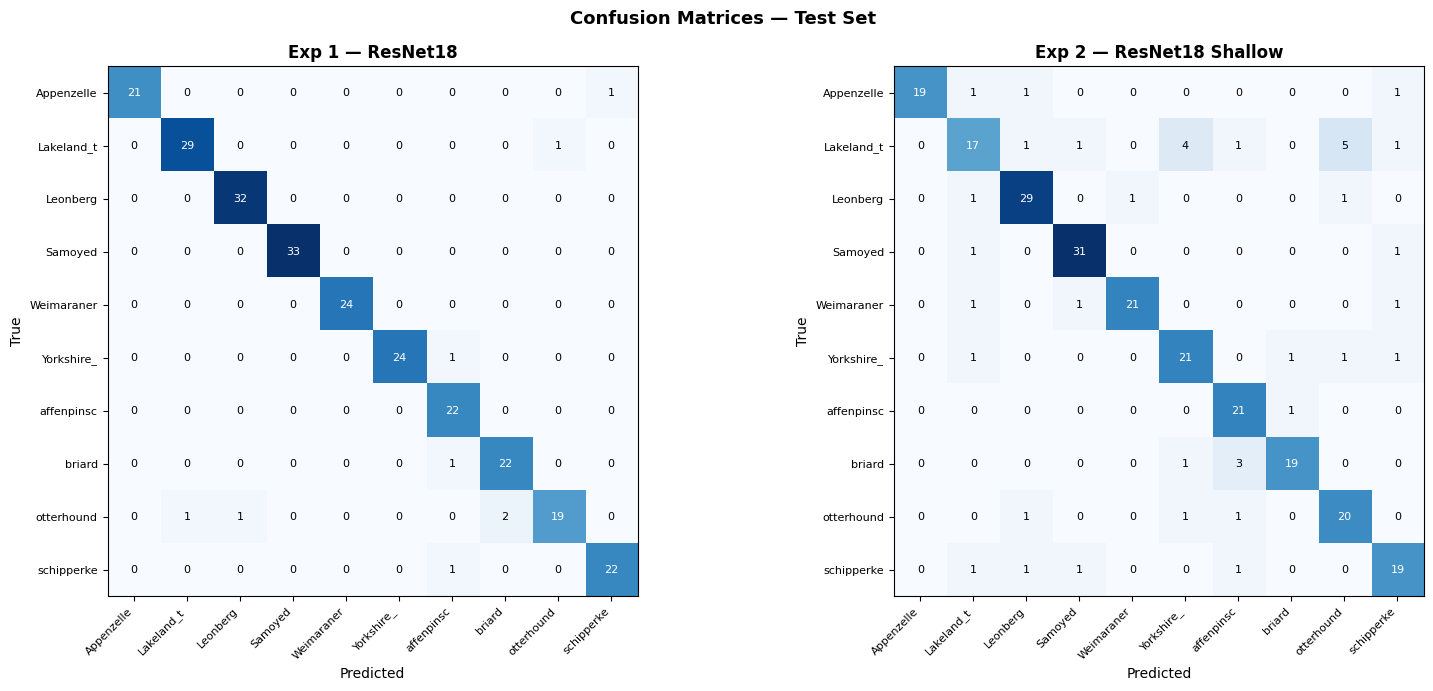

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
short_names = [c[:10] for c in CLASS_NAMES]
for ax, cm, title in [
    (ax1, cm1, "Exp 1 \u2014 ResNet18"),
    (ax2, cm2, "Exp 2 \u2014 ResNet18 Shallow")
]:
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > thresh else "black")
plt.suptitle("Confusion Matrices \u2014 Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_confusion_matrices.png", dpi=150)
plt.show()

### Exp 2 — Lakeland Terrier Misclassifications

The customised model misclassified 4 Lakeland Terriers as Yorkshire Terrier and 5 as Otterhound.
Both confusions are driven by shared coat texture — the shallower model lacks the high-level
spatial features from `layer4` needed to distinguish body size and ear shape.

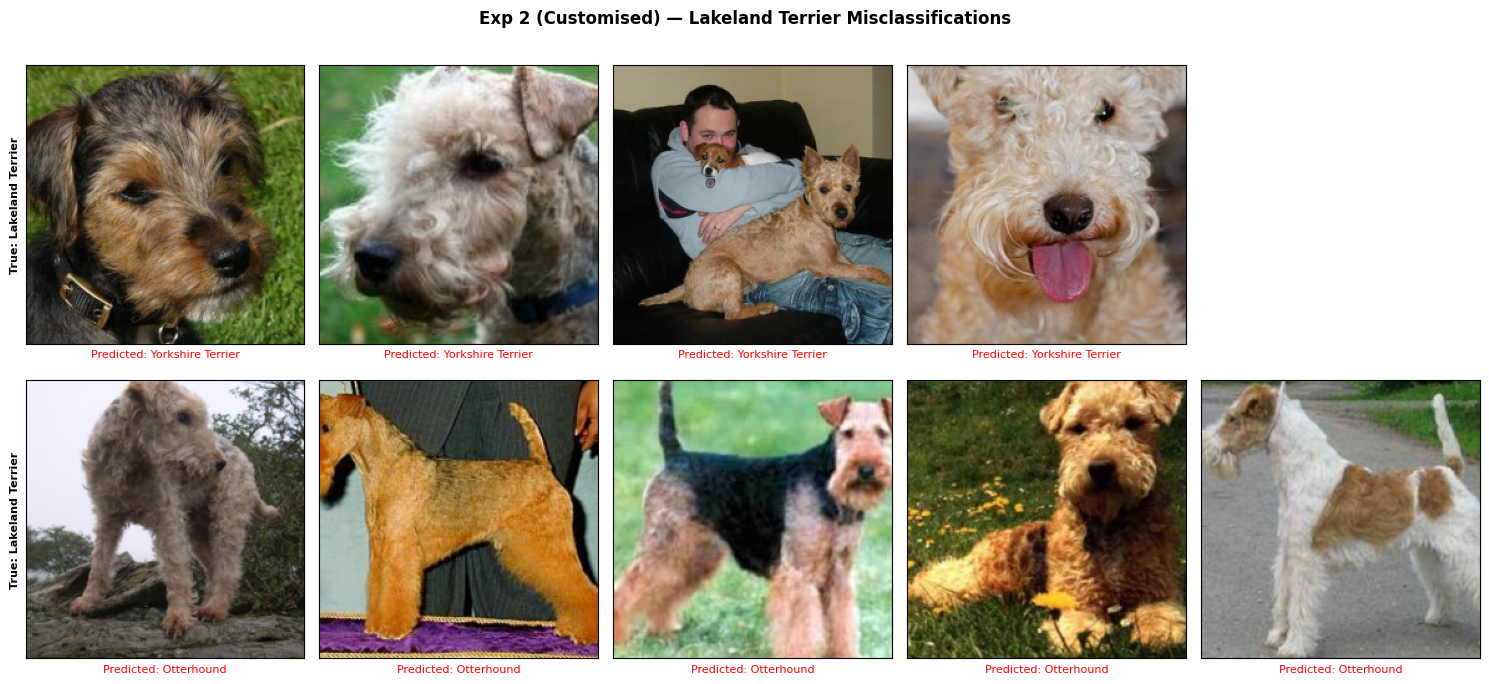

Lakeland Terriers misclassified as Yorkshire Terrier: 4
Lakeland Terriers misclassified as Otterhound:        5


In [12]:
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(img_t):
    return (img_t * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy()

LAKELAND_IDX  = CLASS_NAMES.index("Lakeland_terrier")
YORKSHIRE_IDX = CLASS_NAMES.index("Yorkshire_terrier")
OTTERHOUND_IDX = CLASS_NAMES.index("otterhound")

as_yorkshire, as_otterhound = [], []

with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, true_label = test_ds[i]
        if true_label != LAKELAND_IDX:
            continue
        pred = model2(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        if pred == YORKSHIRE_IDX:
            as_yorkshire.append(img_t)
        elif pred == OTTERHOUND_IDX:
            as_otterhound.append(img_t)

groups = [
    (as_yorkshire, "Predicted: Yorkshire Terrier"),
    (as_otterhound, "Predicted: Otterhound"),
]

fig, axes = plt.subplots(2, max(len(as_yorkshire), len(as_otterhound)),
                         figsize=(3 * max(len(as_yorkshire), len(as_otterhound)), 7))

for row, (imgs, group_label) in enumerate(groups):
    for col in range(axes.shape[1]):
        ax = axes[row, col]
        if col < len(imgs):
            ax.imshow(denorm(imgs[col]))
            ax.set_xlabel(group_label, fontsize=8, color="red")
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel("True: Lakeland Terrier", fontsize=8, fontweight="bold")
        else:
            ax.axis("off")

plt.suptitle("Exp 2 (Customised) — Lakeland Terrier Misclassifications",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_lakeland_misclassifications.png", dpi=150)
plt.show()

print(f"Lakeland Terriers misclassified as Yorkshire Terrier: {len(as_yorkshire)}")
print(f"Lakeland Terriers misclassified as Otterhound:        {len(as_otterhound)}")


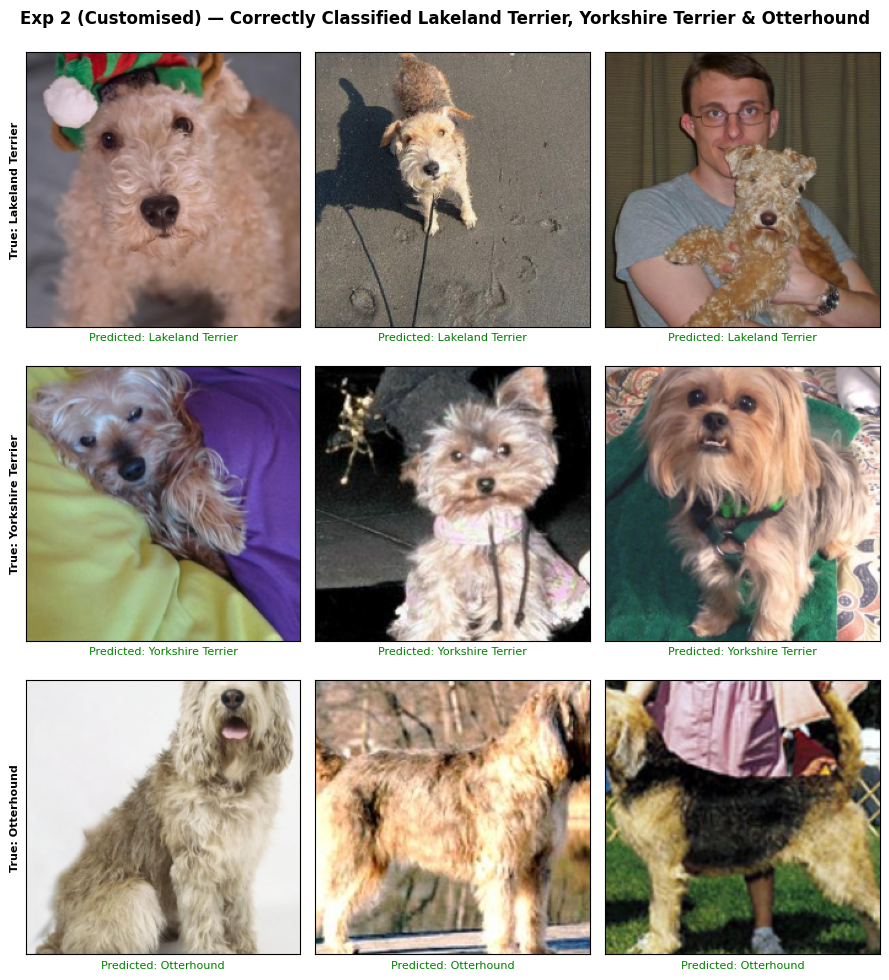

In [15]:
N_CORRECT = 3

def get_correct(model, class_idx, n):
    correct = []
    with torch.no_grad():
        for i in range(len(test_ds)):
            img_t, true_label = test_ds[i]
            if true_label != class_idx:
                continue
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
            if pred == true_label:
                correct.append(img_t)
            if len(correct) >= n:
                break
    return correct

yorkshire_correct = get_correct(model2, YORKSHIRE_IDX,  N_CORRECT)
otterhound_correct = get_correct(model2, OTTERHOUND_IDX, N_CORRECT)
lakeland_correct  = get_correct(model2, LAKELAND_IDX,   N_CORRECT)

groups = [
    (lakeland_correct,  "Lakeland Terrier"),
    (yorkshire_correct, "Yorkshire Terrier"),
    (otterhound_correct, "Otterhound"),
]

fig, axes = plt.subplots(3, N_CORRECT, figsize=(3 * N_CORRECT, 10))

for row, (imgs, label) in enumerate(groups):
    for col, img_t in enumerate(imgs):
        ax = axes[row, col]
        ax.imshow(denorm(img_t))
        ax.set_xlabel(f"Predicted: {label}", fontsize=8, color="green")
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"True: {label}", fontsize=8, fontweight="bold")

plt.suptitle("Exp 2 (Customised) — Correctly Classified Lakeland Terrier, Yorkshire Terrier & Otterhound",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_lakeland_yorkshire_otterhound_correct.png", dpi=150)
plt.show()


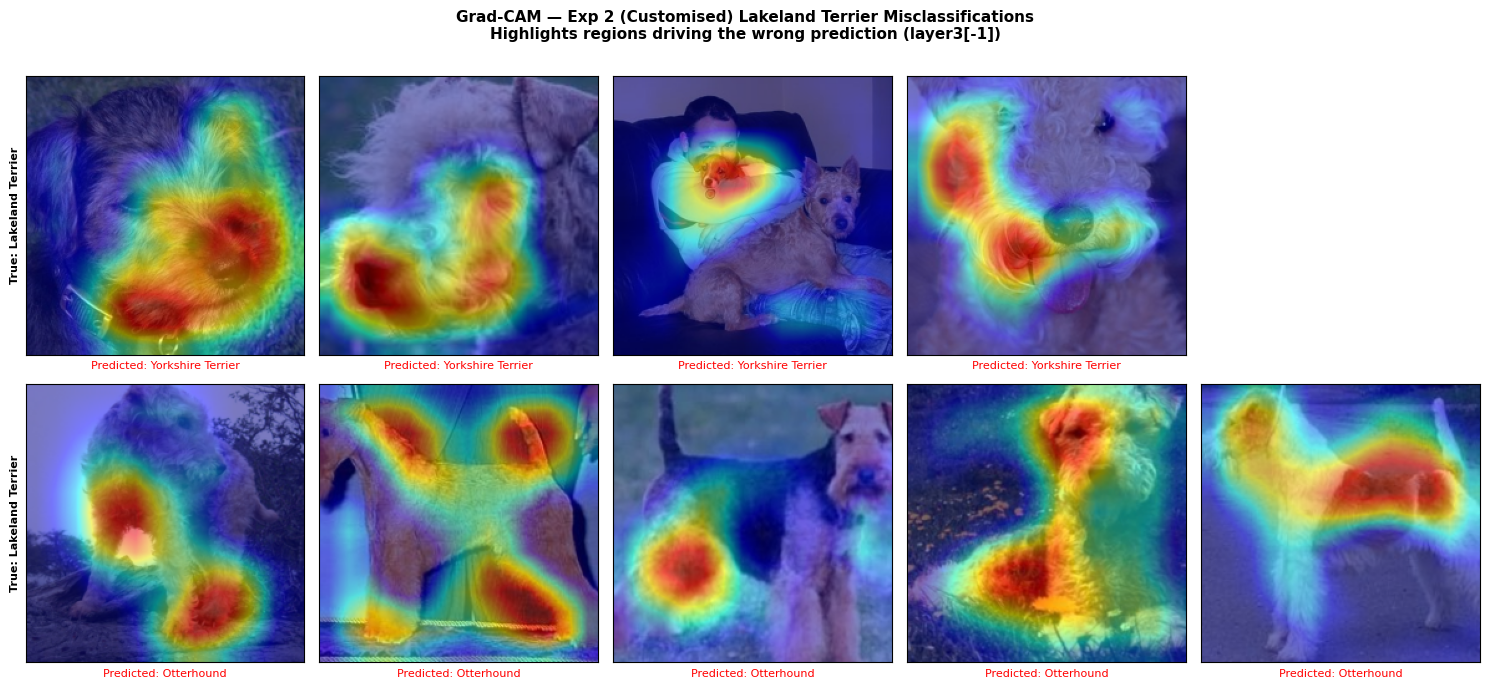

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target layer3[-1] — the deepest layer in the customised model
cam = GradCAM(model=model2, target_layers=[model2.layer3[-1]])

groups = [
    (as_yorkshire,  "Predicted: Yorkshire Terrier"),
    (as_otterhound, "Predicted: Otterhound"),
]

ncols = max(len(as_yorkshire), len(as_otterhound))
fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 7))

for row, (imgs, group_label) in enumerate(groups):
    for col in range(ncols):
        ax = axes[row, col]
        if col < len(imgs):
            img_t        = imgs[col]
            grayscale_cam = cam(input_tensor=img_t.unsqueeze(0).to(DEVICE))[0]
            rgb_img       = denorm(img_t).astype(np.float32)
            overlay       = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
            ax.imshow(overlay)
            ax.set_xlabel(group_label, fontsize=8, color="red")
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel("True: Lakeland Terrier", fontsize=8, fontweight="bold")
        else:
            ax.axis("off")

plt.suptitle(
    "Grad-CAM — Exp 2 (Customised) Lakeland Terrier Misclassifications\n"
    "Highlights regions driving the wrong prediction (layer3[-1])",
    fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_gradcam_lakeland.png", dpi=150)
plt.show()


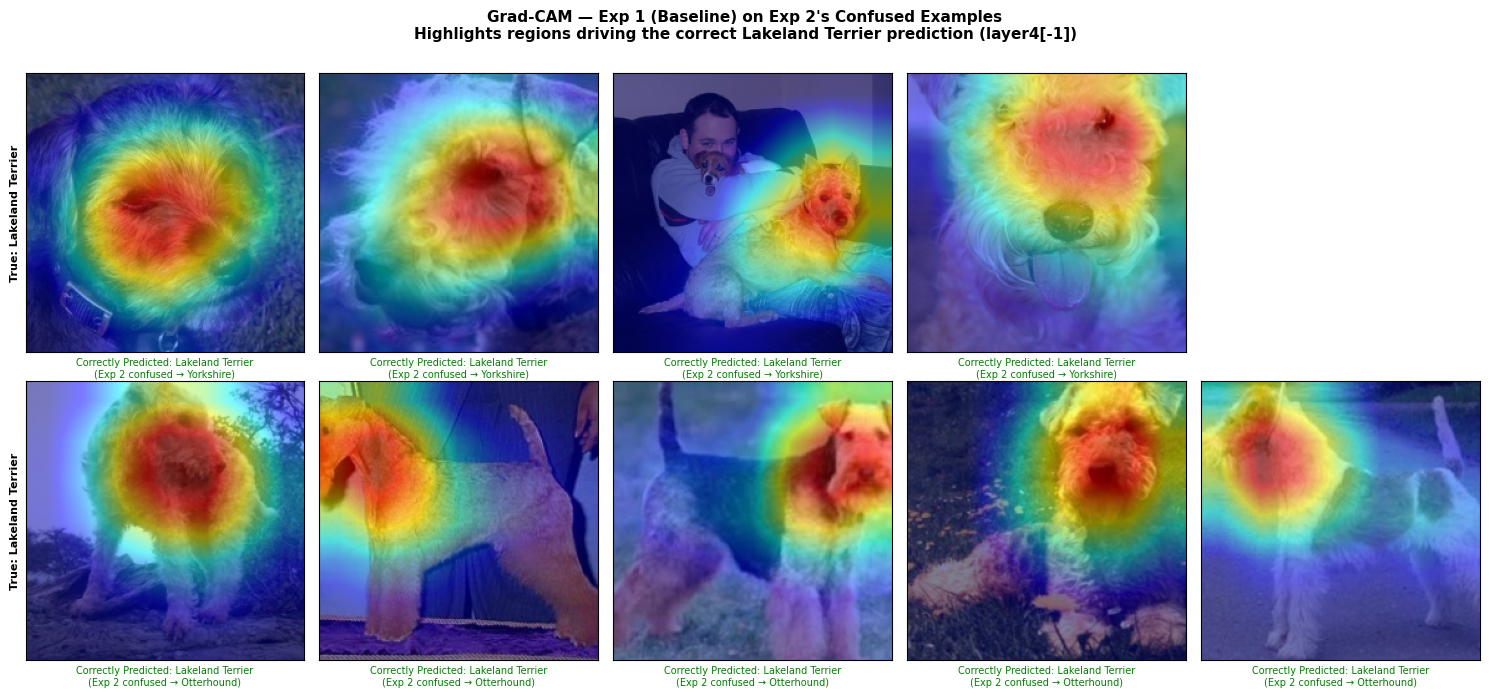

In [18]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target layer4[-1] — the deepest layer in the baseline model
cam1 = GradCAM(model=model1, target_layers=[model1.layer4[-1]])

# Force target class to Lakeland Terrier — model1 gets these right
lakeland_target = [ClassifierOutputTarget(LAKELAND_IDX)]

groups = [
    (as_yorkshire,  "Correctly Predicted: Lakeland Terrier\n(Exp 2 confused → Yorkshire)"),
    (as_otterhound, "Correctly Predicted: Lakeland Terrier\n(Exp 2 confused → Otterhound)"),
]

ncols = max(len(as_yorkshire), len(as_otterhound))
fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 7))

for row, (imgs, group_label) in enumerate(groups):
    for col in range(ncols):
        ax = axes[row, col]
        if col < len(imgs):
            img_t         = imgs[col]
            grayscale_cam = cam1(input_tensor=img_t.unsqueeze(0).to(DEVICE),
                                 targets=lakeland_target)[0]
            rgb_img       = denorm(img_t).astype(np.float32)
            overlay       = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
            ax.imshow(overlay)
            ax.set_xlabel(group_label, fontsize=7, color="green")
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel("True: Lakeland Terrier", fontsize=8, fontweight="bold")
        else:
            ax.axis("off")

plt.suptitle(
    "Grad-CAM — Exp 1 (Baseline) on Exp 2's Confused Examples\n"
    "Highlights regions driving the correct Lakeland Terrier prediction (layer4[-1])",
    fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_gradcam_lakeland_exp1.png", dpi=150)
plt.show()
